In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
np.random.seed(42)
tf.random.set_seed(42)
print("All imports successful!")

I0000 00:00:1775110962.561815    7681 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775110962.594563    7681 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All imports successful!


I0000 00:00:1775110963.398986    7681 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
DATA_PATH = 'data'
MODEL_PATH = 'models'
YES_PATH = os.path.join(DATA_PATH, 'yes')
NO_PATH = os.path.join(DATA_PATH, 'no')
os.makedirs(MODEL_PATH, exist_ok=True)
print("Configuration complete!")

Configuration complete!


In [3]:
def load_images_from_folder(folder_path, label):
    images = []
    labels = []
    if not os.path.exists(folder_path):
        print(f"Warning: {folder_path} does not exist")
        return images, labels
    files = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        files.extend(glob(os.path.join(folder_path, ext)))
    print(f"Loading {len(files)} images from {folder_path}")
    for img_file in files:
        try:
            img = cv2.imread(img_file)
            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img.astype('float32') / 255.0
                images.append(img)
                labels.append(label)
        except Exception as e:
            print(f"Error: {e}")
    return images, labels
print("Loading tumor images (yes)...")
yes_images, yes_labels = load_images_from_folder(YES_PATH, 1)
print("Loading no tumor images (no)...")
no_images, no_labels = load_images_from_folder(NO_PATH, 0)
all_images = yes_images + no_images
all_labels = yes_labels + no_labels
print(f"Total images: {len(all_images)}")

Loading tumor images (yes)...
Loading 155 images from data/yes
Loading no tumor images (no)...
Loading 98 images from data/no
Total images: 253


In [4]:
X = np.array(all_images)
y = np.array(all_labels)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Image shape: {X_train[0].shape}")

Training samples: 202
Testing samples: 51
Image shape: (224, 224, 3)


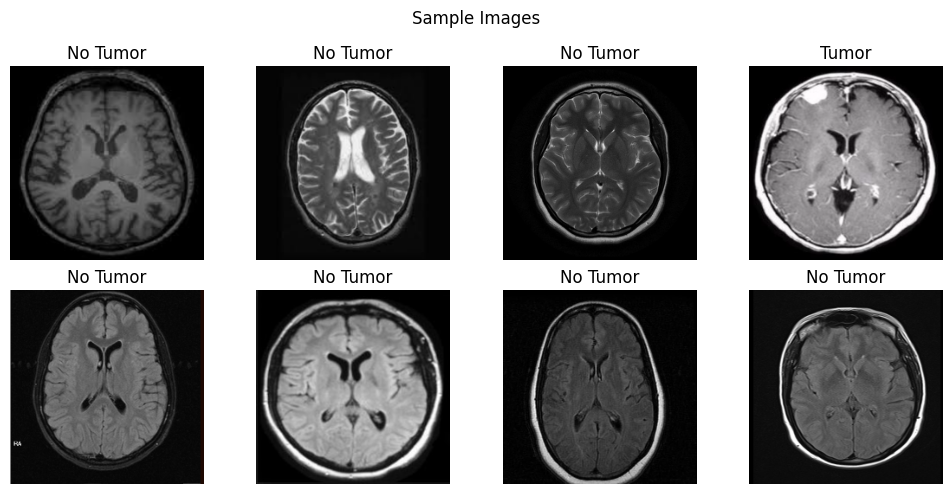

In [5]:
plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train[i])
    plt.title('Tumor' if y_train[i] == 1 else 'No Tumor')
    plt.axis('off')
plt.suptitle('Sample Images')
plt.tight_layout()
plt.show()

In [6]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

/home/sn1per/Desktop/Projects/tumour/tumour_env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1775110966.743537    7681 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,281 (42.64 MB)

 Trainable params: 11,177,281 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 667ms/step - accuracy: 0.5912 - loss: 0.8088 - val_accuracy: 0.8095 - val_loss: 0.6394
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 607ms/step - accuracy: 0.6851 - loss: 0.6406 - val_accuracy: 0.8095 - val_loss: 0.5195
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 611ms/step - accuracy: 0.7790 - loss: 0.5398 - val_accuracy: 0.8571 - val_loss: 0.4530
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 621ms/step - accuracy: 0.7901 - loss: 0.5392 - val_accuracy: 0.8571 - val_loss: 0.4523
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 604ms/step - accuracy: 0.8122 - loss: 0.5046 - val_accuracy: 0.9048 - val_loss: 0.4155
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 632ms/step - accuracy: 0.8177 - loss: 0.4791 - val_accuracy: 0.9048 - val_loss: 0.4152
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 624ms/step - accuracy: 0.8177 - loss: 0.4317 - val_accuracy: 0.9048 - val_loss: 0.4130
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 595ms/step - accuracy: 0.8564 - loss: 0.3695 - val_accuracy: 0.9048 - val_loss:

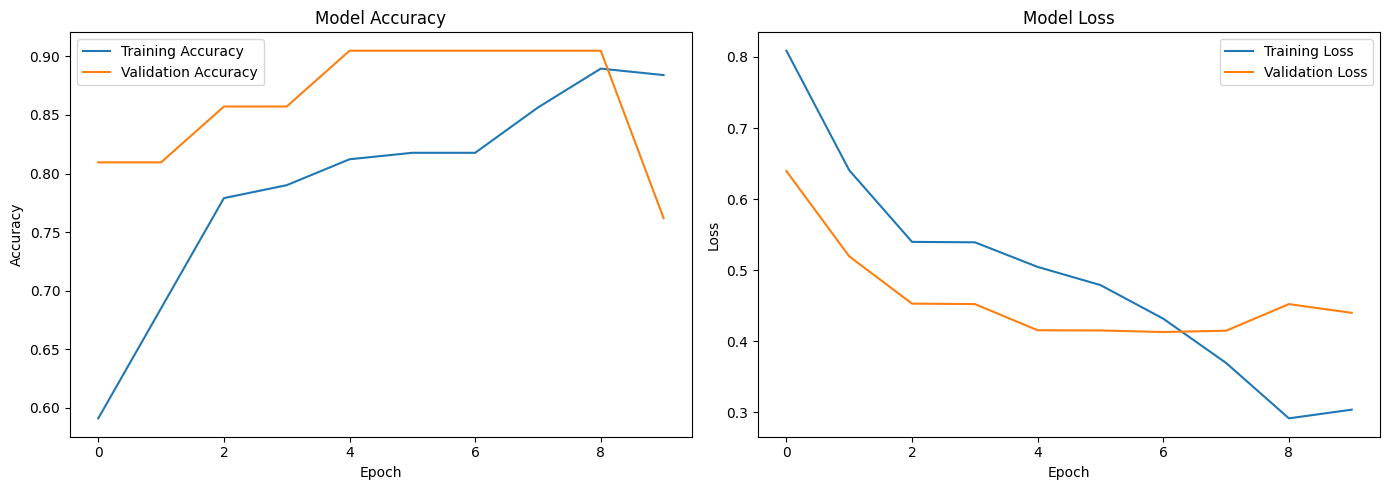

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.savefig(MODEL_PATH + '/training_history.png', dpi=150)
plt.show()

Test Loss: 0.4158
Test Accuracy: 0.7647 (76.47%)

Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.72      0.65      0.68        20
       Tumor       0.79      0.84      0.81        31

    accuracy                           0.76        51
   macro avg       0.76      0.74      0.75        51
weighted avg       0.76      0.76      0.76        51



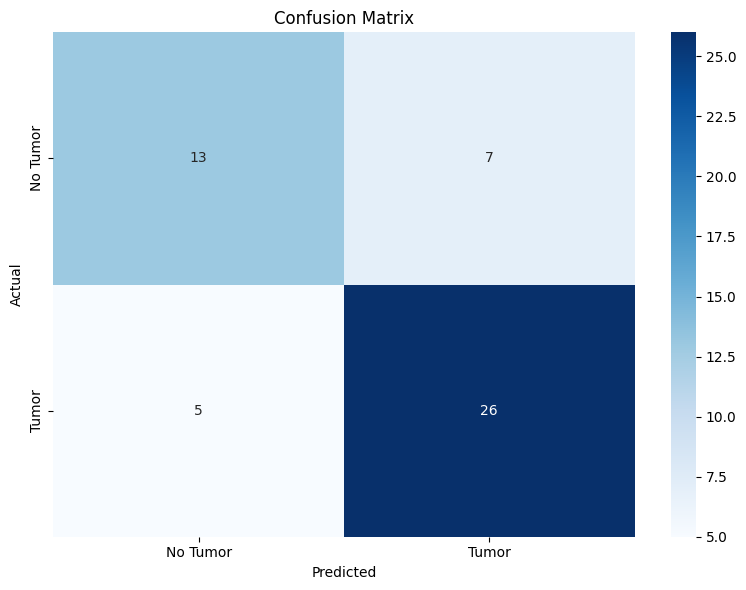

In [9]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Tumor', 'Tumor']))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(MODEL_PATH + '/confusion_matrix.png', dpi=150)
plt.show()

In [10]:
model.save(MODEL_PATH + '/brain_tumor_model.keras')
print("Model saved!")

Model saved!


In [11]:
def predict_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load {image_path}")
        return
    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img, verbose=0)[0][0]
    if prediction > 0.5:
        result = "Tumor Detected"
        confidence = prediction * 100
    else:
        result = "No Tumor"
        confidence = (1 - prediction) * 100
    plt.figure(figsize=(6, 4))
    plt.imshow(original)
    plt.axis('off')
    plt.title(f"{result}\nConfidence: {confidence:.2f}%")
    plt.show()
    return result, confidence
idx = np.random.randint(0, len(X_test))
test_img = np.expand_dims(X_test[idx], axis=0)
pred = model.predict(test_img, verbose=0)[0][0]
actual = "Tumor" if y_test[idx] == 1 else "No Tumor"
predicted = "Tumor" if pred > 0.5 else "No Tumor"
print(f"Actual: {actual}, Predicted: {predicted}")

Actual: Tumor, Predicted: Tumor


In [12]:
print("="*60)
print("PROJECT COMPLETE!")
print("="*60)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Model saved to: {MODEL_PATH}/brain_tumor_model.keras")

PROJECT COMPLETE!
Test Accuracy: 76.47%
Model saved to: models/brain_tumor_model.keras
